# **Capítulo 4: Series de Tiempo.  Caso de Estudio 2: Twlo prices**

```
Libro: Investigación en Ciencia de Datos
```

**Autora:** Dora María Ballesteros  
Universidad Militar Nueva Granada (UMNG)

---


### Material complementario del libro

Este notebook acompaña el **Capítulo 4** del libro y desarrolla el **Caso de Estudio 2: Twlo prices**, incluyendo los ejemplos, análisis y experimentos presentados a lo largo del capítulo.

Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.


# **1. ANÁLISIS EXPLORATORIO DE LOS DATOS**

**VISUALIZACIÓN DEL CONTENIDO DEL DATASET**

In [1]:
import pandas as pd
price_df = pd.read_csv("/content/twlo_prices.csv")
price_df.head(10)

,close,volume,date
0,99.9800,93417.0,2020-01-02 14:30:00+00:00
1,99.7800,16685.0,2020-01-02 14:31:00+00:00
2,100.1400,21998.0,2020-01-02 14:32:00+00:00
3,100.3500,18348.0,2020-01-02 14:33:00+00:00
4,100.5500,22181.0,2020-01-02 14:34:00+00:00
5,100.6100,14573.0,2020-01-02 14:35:00+00:00
6,100.9500,13960.0,2020-01-02 14:36:00+00:00
7,100.9875,20219.0,2020-01-02 14:37:00+00:00
8,101.0500,10588.0,2020-01-02 14:38:00+00:00
9,101.1400,14118.0,2020-01-02 14:39:00+00:00


**TAMAÑO DEL DATASET**

In [2]:
price_df.shape
# La cantidad de filas es 146502 y la cantidad de columnas es 3

(146502, 3)

**INFORMACIÓN DEL DATASET**

In [3]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146502 entries, 0 to 146501
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   close   146502 non-null  float64
 1   volume  146502 non-null  float64
 2   date    146502 non-null  object 
dtypes: float64(2), object(1)
memory usage: 3.4+ MB


**CONVERTIR LA COLUMNA "DATE" EN UN INDEX DEL DATAFRAME**

La ventaja de realizar esta conversión es que el nuevo índice facilita la realización de diferentes operaciones, como la generación de gráficas asociadas a él.

**a. Creación del nuevo index a partir de la info de "date"**

In [4]:
# Conversión de la columna date a formato datetime
price_df['date'] = pd.to_datetime(price_df['date'])

# Definir la fecha como índice temporal
price_df = price_df.set_index('date')

# Verificar estructura final
price_df.head(10)

,close,volume
date,,
2020-01-02 14:30:00+00:00,99.9800,93417.0
2020-01-02 14:31:00+00:00,99.7800,16685.0
2020-01-02 14:32:00+00:00,100.1400,21998.0
2020-01-02 14:33:00+00:00,100.3500,18348.0
2020-01-02 14:34:00+00:00,100.5500,22181.0
2020-01-02 14:35:00+00:00,100.6100,14573.0
2020-01-02 14:36:00+00:00,100.9500,13960.0
2020-01-02 14:37:00+00:00,100.9875,20219.0
2020-01-02 14:38:00+00:00,101.0500,10588.0


**b. Se ordena el dataframe a partir del Index**

In [5]:
price_df.sort_index(inplace=True)
print(price_df.index)

DatetimeIndex(['2020-01-02 14:30:00+00:00', '2020-01-02 14:31:00+00:00',
               '2020-01-02 14:32:00+00:00', '2020-01-02 14:33:00+00:00',
               '2020-01-02 14:34:00+00:00', '2020-01-02 14:35:00+00:00',
               '2020-01-02 14:36:00+00:00', '2020-01-02 14:37:00+00:00',
               '2020-01-02 14:38:00+00:00', '2020-01-02 14:39:00+00:00',
               ...
               '2021-07-08 19:50:00+00:00', '2021-07-08 19:51:00+00:00',
               '2021-07-08 19:52:00+00:00', '2021-07-08 19:53:00+00:00',
               '2021-07-08 19:54:00+00:00', '2021-07-08 19:55:00+00:00',
               '2021-07-08 19:56:00+00:00', '2021-07-08 19:57:00+00:00',
               '2021-07-08 19:58:00+00:00', '2021-07-08 19:59:00+00:00'],
              dtype='datetime64[ns, UTC]', name='date', length=146502, freq=None)


**VISUALIZACIÓN DE LA SERIE TEMPORAL (VOLUME, CLOSE)**

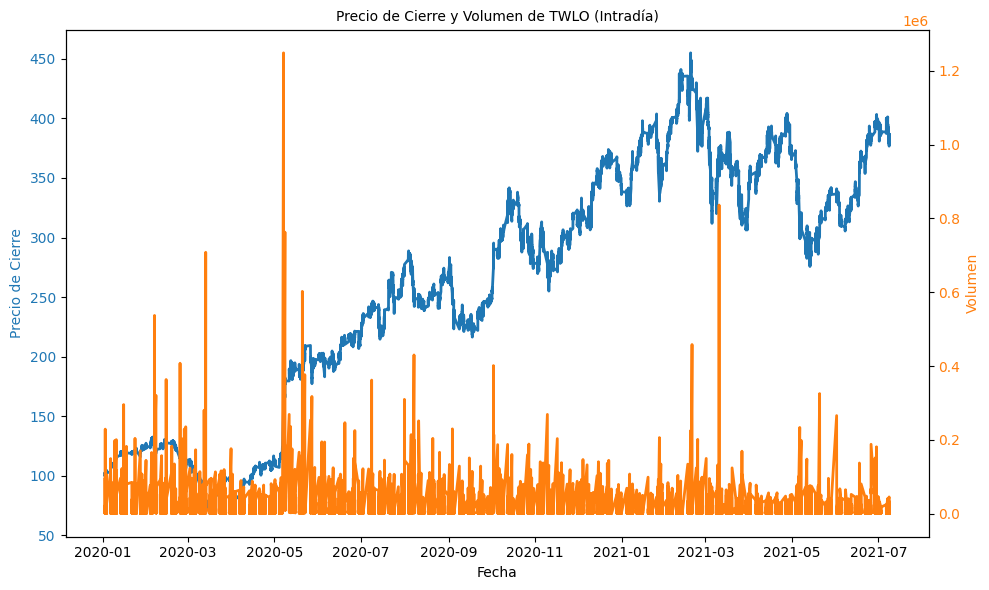

In [6]:
import matplotlib.pyplot as plt

# Crear subgráficos
fig, ax1 = plt.subplots(figsize=(10, 6))

# Graficar 'close' en el primer eje
ax1.plot(price_df.index, price_df['close'], color='tab:blue', label='Close', linewidth=2)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio de Cierre', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Crear un segundo eje para 'volume'
ax2 = ax1.twinx()
ax2.plot(price_df.index, price_df['volume'], color='tab:orange', label='Volume', linewidth=2)
ax2.set_ylabel('Volumen', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Añadir título
plt.title('Precio de Cierre y Volumen de TWLO (Intradía)', fontsize=10)

# Mostrar gráfico
plt.tight_layout()
plt.show()

**CONSTRUCCIÓN DE LA VARIABLE DE SALIDA**

**a. Calcular el precio de cierre de cada dia**

In [7]:
daily_close = price_df['close'].resample('1D').last().dropna()
daily_close.head(10)

,close
date,
2020-01-02 00:00:00+00:00,103.15
2020-01-03 00:00:00+00:00,103.52
2020-01-06 00:00:00+00:00,107.46
2020-01-07 00:00:00+00:00,108.09
2020-01-08 00:00:00+00:00,109.38
2020-01-09 00:00:00+00:00,113.02
2020-01-10 00:00:00+00:00,115.75
2020-01-13 00:00:00+00:00,120.32
2020-01-14 00:00:00+00:00,119.02


**b.  Retorno diario**

In [8]:
#Retorno diario
daily_ret = daily_close.pct_change()
print(daily_ret)

date
2020-01-02 00:00:00+00:00         NaN
2020-01-03 00:00:00+00:00    0.003587
2020-01-06 00:00:00+00:00    0.038060
2020-01-07 00:00:00+00:00    0.005863
2020-01-08 00:00:00+00:00    0.011934
                               ...   
2021-07-01 00:00:00+00:00   -0.018971
2021-07-02 00:00:00+00:00    0.004886
2021-07-06 00:00:00+00:00    0.014639
2021-07-07 00:00:00+00:00   -0.014985
2021-07-08 00:00:00+00:00   -0.009885
Name: close, Length: 382, dtype: float64


In [9]:
print(daily_ret.shift(-1))

date
2020-01-02 00:00:00+00:00    0.003587
2020-01-03 00:00:00+00:00    0.038060
2020-01-06 00:00:00+00:00    0.005863
2020-01-07 00:00:00+00:00    0.011934
2020-01-08 00:00:00+00:00    0.033278
                               ...   
2021-07-01 00:00:00+00:00    0.004886
2021-07-02 00:00:00+00:00    0.014639
2021-07-06 00:00:00+00:00   -0.014985
2021-07-07 00:00:00+00:00   -0.009885
2021-07-08 00:00:00+00:00         NaN
Name: close, Length: 382, dtype: float64


**c.  Creación de "daily_target" utilizando un umbral mínimo de variación**

In [10]:
# Umbral mínimo de variación (0.2%)
threshold = 0.002

# Variable objetivo: ¿sube el precio al día siguiente?
daily_target = (daily_ret.shift(-1) > threshold).astype(int)

print(daily_target)

daily_target.value_counts()

date
2020-01-02 00:00:00+00:00    1
2020-01-03 00:00:00+00:00    1
2020-01-06 00:00:00+00:00    1
2020-01-07 00:00:00+00:00    1
2020-01-08 00:00:00+00:00    1
                            ..
2021-07-01 00:00:00+00:00    1
2021-07-02 00:00:00+00:00    1
2021-07-06 00:00:00+00:00    0
2021-07-07 00:00:00+00:00    0
2021-07-08 00:00:00+00:00    0
Name: close, Length: 382, dtype: int64


,count
close,
1,200
0,182


**Columna auxiliar con el dia**

In [11]:
price_df['day'] = price_df.index.floor('D')

price_df.head(10)

,close,volume,day
date,,,
2020-01-02 14:30:00+00:00,99.9800,93417.0,2020-01-02 00:00:00+00:00
2020-01-02 14:31:00+00:00,99.7800,16685.0,2020-01-02 00:00:00+00:00
2020-01-02 14:32:00+00:00,100.1400,21998.0,2020-01-02 00:00:00+00:00
2020-01-02 14:33:00+00:00,100.3500,18348.0,2020-01-02 00:00:00+00:00
2020-01-02 14:34:00+00:00,100.5500,22181.0,2020-01-02 00:00:00+00:00
2020-01-02 14:35:00+00:00,100.6100,14573.0,2020-01-02 00:00:00+00:00
2020-01-02 14:36:00+00:00,100.9500,13960.0,2020-01-02 00:00:00+00:00
2020-01-02 14:37:00+00:00,100.9875,20219.0,2020-01-02 00:00:00+00:00
2020-01-02 14:38:00+00:00,101.0500,10588.0,2020-01-02 00:00:00+00:00


**Fusionar los dos datasets**

In [12]:
# Unir la variable objetivo diaria al dataset intradía
price_df = price_df.merge(
    daily_target.rename('target'),
    left_on='day',
    right_index=True,
    how='inner'
)

# Eliminar columna auxiliar
price_df.drop(columns=['day'], inplace=True)

price_df.head(20)

,close,volume,target
date,,,
2020-01-02 14:30:00+00:00,99.9800,93417.0,1
2020-01-02 14:31:00+00:00,99.7800,16685.0,1
2020-01-02 14:32:00+00:00,100.1400,21998.0,1
2020-01-02 14:33:00+00:00,100.3500,18348.0,1
2020-01-02 14:34:00+00:00,100.5500,22181.0,1
2020-01-02 14:35:00+00:00,100.6100,14573.0,1
2020-01-02 14:36:00+00:00,100.9500,13960.0,1
2020-01-02 14:37:00+00:00,100.9875,20219.0,1
2020-01-02 14:38:00+00:00,101.0500,10588.0,1


**Visualización del nuevo dataset**

In [13]:
# visualización del dataset
price_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 146502 entries, 2020-01-02 14:30:00+00:00 to 2021-07-08 19:59:00+00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   close   146502 non-null  float64
 1   volume  146502 non-null  float64
 2   target  146502 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 4.5 MB


# **2. ENTRENAMIENTO DEL MODELO Y PREDICCIÓN ANTES DE APLICAR FE**

**PREPARACIÓN DEL DATASET**

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.tree import plot_tree

X = price_df.drop(columns=["target"])
y = price_df["target"]

In [15]:
y.value_counts(normalize=True)

,proportion
target,
1,0.524273
0,0.475727


**SPLIT ENTRE ENTRENAMIENTO Y VALIDACIÓN (TEST INTERNO)**

In [16]:
# Split temporal (70%-30%)
split = int(len(price_df) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

**MODELAMIENTO CON ÁRBOL DE DECISIÓN**

Accuracy: 0.56

Matriz de Confusión:
[[ 8207 15185]
 [ 4078 16481]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    No subió       0.67      0.35      0.46     23392
       Subió       0.52      0.80      0.63     20559

    accuracy                           0.56     43951
   macro avg       0.59      0.58      0.55     43951
weighted avg       0.60      0.56      0.54     43951



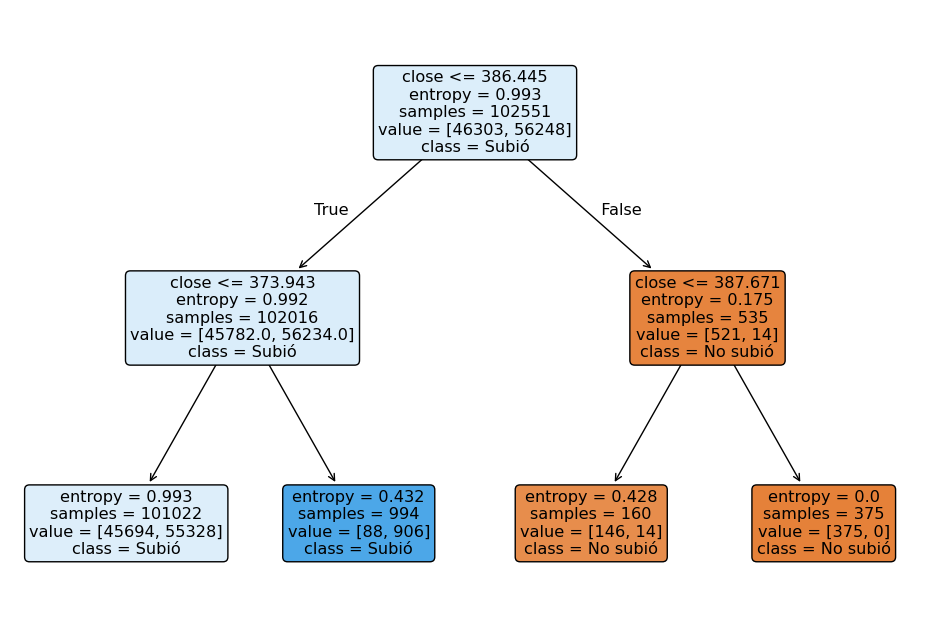

In [17]:
# Modelamiento

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Modelo base: Árbol de decisión
model = DecisionTreeClassifier(criterion="entropy", max_depth=2, random_state=42)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No subió", "Subió"]))

# Visualización del árbol
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No subió", "Subió"],
    filled=True,
    rounded=True
)
plt.show()


# **3. INGENIERÍA DE CARACTERÍSTICAS CON SELECCIÓN ESTADÍSTICA**


 **FE "estadística" y eficiente para Series de Tiempo (twlo_prices)**
 - Selección de LAGS: Mutual Information (MI) sobre retornos
 - Selección de VENTANAS: tiempo de decorrelación (tau) vía ACF
 - Generación de features: lags + rolling (mean/std) + expanding
 Requiere: price_df con columnas ['close','volume','target'] e índice datetime


In [18]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf
from sklearn.feature_selection import mutual_info_classif

def add_statistical_fe(
    price_df: pd.DataFrame,
    max_lag: int = 60,
    top_k_lags: int = 8,
    acf_nlags: int = 200,
    acf_threshold: float = 0.05,
    use_expanding: bool = True,
):
    df = price_df.copy()

    # --- 0) Orden y checks ---
    df = df.sort_index()
    required = {"close", "volume", "target"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    # --- 1) Selección de ventanas rolling usando ACF -> tiempo de decorrelación (tau) ---
    r = df["close"].dropna()
    if len(r) < 50:
        raise ValueError("Muy pocos datos para estimar ACF de forma estable.")

    acf_vals = acf(r, nlags=min(acf_nlags, len(r) - 1), fft=True)
    # Primer lag donde |ACF| cae por debajo del umbral
    tau = next((i for i in range(1, len(acf_vals)) if abs(acf_vals[i]) < acf_threshold), 20)

    # Ventanas alrededor de tau (redondeadas y con mínimos razonables)
    windows = sorted({max(3, int(round(tau / 2))), max(3, int(round(tau))), max(5, int(round(2 * tau)))})
    # Si tau es muy pequeño, añade una ventana un poco más larga para estabilidad
    if windows[-1] < 10:
        windows = sorted(set(windows + [10, 20]))

    # --- 2) Selección de lags usando Mutual Information (MI) ---
    # Creamos candidatos de lags sobre retornos (ret)
    X_lags = pd.concat({f"close_lag_{k}": df["close"].shift(k) for k in range(1, max_lag + 1)}, axis=1)
    tmp_mi = pd.concat([X_lags, df["target"]], axis=1).dropna()

    if len(tmp_mi) < 200:
        # Si hay pocos datos (por NaNs), baja max_lag automáticamente
        new_max_lag = max(10, min(max_lag, len(df) // 20))
        X_lags = pd.concat({f"close_lag_{k}": df["close"].shift(k) for k in range(1, new_max_lag + 1)}, axis=1)
        tmp_mi = pd.concat([X_lags, df["target"]], axis=1).dropna()

    mi = mutual_info_classif(
        tmp_mi.drop(columns=["target"]),
        tmp_mi["target"],
        random_state=42
    )
    mi_rank = (
        pd.Series(mi, index=tmp_mi.drop(columns=["target"]).columns)
        .sort_values(ascending=False)
    )

    # Top-k lags (extrae el número del lag desde el nombre "ret_lag_k")
    selected_lags = [int(name.split("_")[-1]) for name in mi_rank.head(top_k_lags).index]
    selected_lags = sorted(set(selected_lags))

    # --- 3) Construcción de features con lags seleccionados ---
    # Lags de Close
    for k in selected_lags:
        df[f"close_lag_{k}"] = df["close"].shift(k)

    # (Opcional) Lags de volumen en los mismos k (a veces ayuda, a veces no; útil para docencia)
    for k in selected_lags:
        df[f"vol_lag_{k}"] = df["volume"].shift(k)

    # --- 4) Rolling features con ventanas elegidas (sobre Close y volume) ---
    for w in windows:
        # retornos
        df[f"close_roll_mean_{w}"] = df["close"].rolling(window=w).mean()
        df[f"close_roll_std_{w}"] = df["close"].rolling(window=w).std()

        # volumen (se suele beneficiar de suavizado)
        df[f"vol_roll_mean_{w}"] = df["volume"].rolling(window=w).mean()
        df[f"vol_roll_std_{w}"] = df["volume"].rolling(window=w).std()

    # --- 5) Expanding (acumulado histórico sobre Close y volume) ---
    if use_expanding:
        df["close_exp_mean"] = df["close"].expanding().mean()
        df["close_exp_std"]  = df["close"].expanding().std()
        df["vol_exp_mean"] = df["volume"].expanding().mean()
        df["vol_exp_std"]  = df["volume"].expanding().std()

    # --- 6) Dataset final ---
    df_fe = df.dropna().copy()

    # X / y listos para modelar (sin leakage de target)
    X = df_fe.drop(columns=["target"])
    y = df_fe["target"]

    # Parámetros seleccionados
    meta = {
        "tau_acf": tau,
        "acf_threshold": acf_threshold,
        "rolling_windows": windows,
        "selected_lags_mi": selected_lags,
        "top_k_lags": top_k_lags,
        "max_lag_considered": max_lag,
    }

    return X, y, df_fe, meta

**CÁLCULO DE NUEVOS FEATURES MEDIANTE LA FUNCIÓN add_statistical_fe**

In [19]:
X_fe, y_fe, price_df_fe, fe_meta = add_statistical_fe(price_df)

print("Selección FE (estadística):")
print(fe_meta)
print("Shape con FE:", X_fe.shape, y_fe.shape)

Selección FE (estadística):
{'tau_acf': 20, 'acf_threshold': 0.05, 'rolling_windows': [10, 20, 40], 'selected_lags_mi': [1, 2, 3, 4, 6, 9, 10, 12], 'top_k_lags': 8, 'max_lag_considered': 60}
Shape con FE: (146463, 34) (146463,)


**CÁLCULO DE LA DISTRIBUCIÓN DEL DATASET (CLASIFICACIÓN BINARIA)**

In [20]:
y_fe.value_counts(normalize=True)


,proportion
target,
1,0.524146
0,0.475854


**VISUALIZACIÓN DE NUEVOS FEATURES**

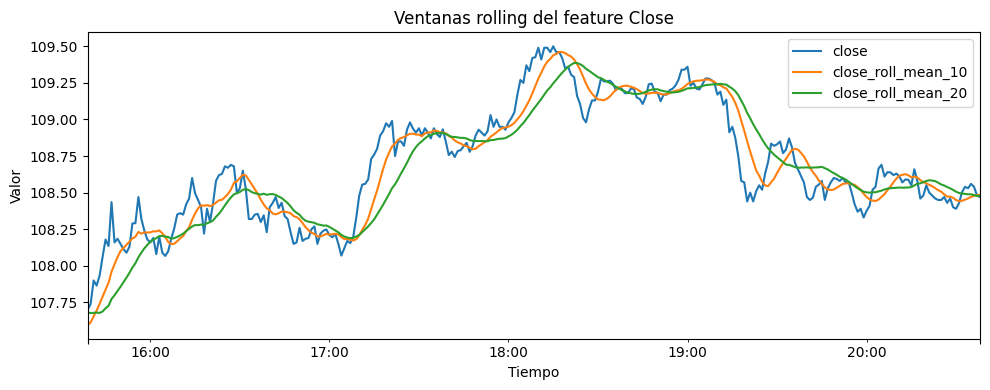

In [21]:
cols = ['close', 'close_roll_mean_10', 'close_roll_mean_20']

# Seleccionar un tramo continuo y eliminar NaNs
plot_df = price_df_fe[cols].dropna().iloc[1200:1500]

plot_df.plot(figsize=(10, 4))
plt.title("Ventanas rolling del feature Close")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()


**INFORMACIÓN DEL DATASET ACTUALIZADO**

In [22]:
price_df_fe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 146463 entries, 2020-01-02 15:09:00+00:00 to 2021-07-08 19:59:00+00:00
Data columns (total 35 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   close               146463 non-null  float64
 1   volume              146463 non-null  float64
 2   target              146463 non-null  int64  
 3   close_lag_1         146463 non-null  float64
 4   close_lag_2         146463 non-null  float64
 5   close_lag_3         146463 non-null  float64
 6   close_lag_4         146463 non-null  float64
 7   close_lag_6         146463 non-null  float64
 8   close_lag_9         146463 non-null  float64
 9   close_lag_10        146463 non-null  float64
 10  close_lag_12        146463 non-null  float64
 11  vol_lag_1           146463 non-null  float64
 12  vol_lag_2           146463 non-null  float64
 13  vol_lag_3           146463 non-null  float64
 14  vol_lag_4           146463 non-null  f

# **4. ENTRENAMIENTO DEL MODELO DESPUÉS DE APLICAR FE**

**TIPO DE MODELO**

In [23]:
print(model)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)


**PREPARACIÓN DEL DATASET Y ENTRENAMIENTO CON EL MISMO TIPO DE MODELO UTILIZADO ANTES DE FE**

Accuracy: 0.53

Matriz de Confusión:
[[23380     0]
 [20559     0]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    No subió       0.53      1.00      0.69     23380
       Subió       0.00      0.00      0.00     20559

    accuracy                           0.53     43939
   macro avg       0.27      0.50      0.35     43939
weighted avg       0.28      0.53      0.37     43939



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


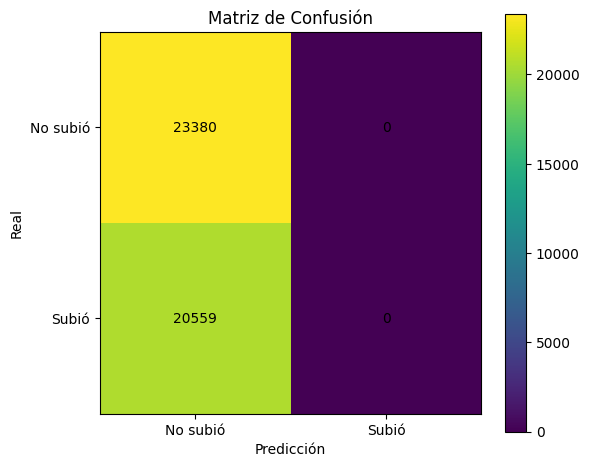

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1) Split temporal (70/30)
split = int(len(X_fe) * 0.7)
X_train, X_test = X_fe.iloc[:split], X_fe.iloc[split:]
y_train, y_test = y_fe.iloc[:split], y_fe.iloc[split:]

# 2) Entrenar y predecir
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3) Métricas
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nMatriz de Confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No subió", "Subió"]))

# 4) Heatmap simple (sin seaborn)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], ["No subió", "Subió"])
plt.yticks([0, 1], ["No subió", "Subió"])

# Valores dentro de la matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

**ACTUALIZACIÓN DE LA PROFUNDIDAD DEL MODELO**

In [25]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_leaf=50,
    random_state=42
)

**NUEVO ENTRENAMIENTO CON LA PROFUNDIDAD DEL MODELO AJUSTADA**

Accuracy: 0.56

Matriz de Confusión:
[[ 8188 15192]
 [ 4043 16516]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    No subió       0.67      0.35      0.46     23380
       Subió       0.52      0.80      0.63     20559

    accuracy                           0.56     43939
   macro avg       0.60      0.58      0.55     43939
weighted avg       0.60      0.56      0.54     43939



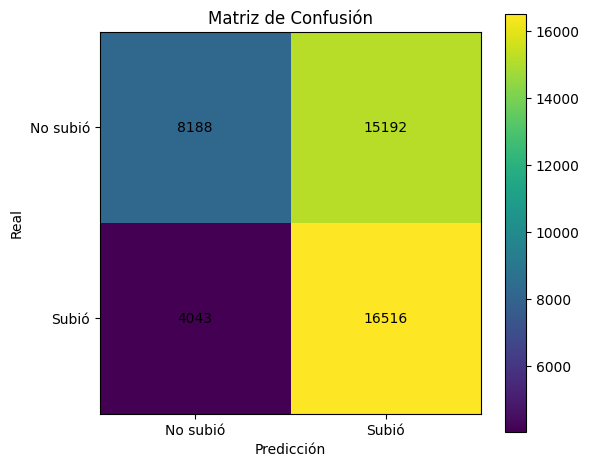

In [26]:
split = int(len(X_fe) * 0.7)
X_train, X_test = X_fe.iloc[:split], X_fe.iloc[split:]
y_train, y_test = y_fe.iloc[:split], y_fe.iloc[split:]

# 2) Entrenar y predecir
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3) Métricas
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nMatriz de Confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No subió", "Subió"]))

# 4) Heatmap simple (sin seaborn)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], ["No subió", "Subió"])
plt.yticks([0, 1], ["No subió", "Subió"])

# Valores dentro de la matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

**CÁLCULO DE IMPORTANCIA DE LOS FEATURES**

In [27]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Usamos el modelo que ya entrenaste (árbol con profundidad suficiente)
model.fit(X_train, y_train)

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    perm.importances_mean,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(15)


,0
close_roll_mean_20,0.076661
close,0.000000
volume,0.000000
close_lag_1,0.000000
close_lag_3,0.000000
close_lag_2,0.000000
close_lag_6,0.000000
close_lag_9,0.000000
close_lag_10,0.000000
close_lag_4,0.000000


Libro: Investigación en Ciencia de Datos

---


Versión: 2026 – Material complementario para Google Colab.